In [222]:
import polars as pl
from importlib import reload
import options_data_utils
reload(options_data_utils)
from options_data_utils import get_cleaned_options_data, delta_thresholds_calls, delta_thresholds_puts, get_number_of_quotes, get_vol_of_iv_for_delta_bucket
from functools import reduce

In [229]:
def get_number_of_quotes (options_data: pl.DataFrame, delta_thresholds: dict, bucket: str):
    return options_data.group_by("trading_day").agg([
        pl.col("implied_vol")
            .filter(pl.col("delta").is_between(*delta_thresholds[bucket]))
            .count()
            .alias(bucket + "_count"),
        pl.col('expiration').first()
    ]).sort("trading_day")
    
def get_average_iv_for_delta_bucket(options_data: pl.DataFrame, delta_thresholds: dict, bucket: str):
  return options_data.group_by("trading_day").agg([
      pl.col("implied_vol")
        .filter(pl.col("delta").is_between(*delta_thresholds[bucket]))
        .mean()
        .alias(bucket + "_iv"),
    pl.col('expiration').first()
  ]).sort("trading_day")

In [230]:
def fold_join (dfs, join_on, how='left'):
    return reduce(lambda x, y: x.join(y, on=join_on, how=how), dfs)


def get_counts (call_df, put_df, func):
    join_on = ['trading_day', 'expiration']
    call_iv = fold_join([func(call_df,  delta_thresholds_calls, k) for k in delta_thresholds_calls.keys()],
    join_on = join_on,
    how='left'   
    )
    put_iv  = fold_join([func(put_df,  delta_thresholds_puts, k) for k in delta_thresholds_puts.keys()],
    join_on = join_on,
    how='left'   
    )
    return call_iv.join(put_iv, on=join_on, how='left')



In [231]:
def get_vol_of_iv_for_delta_bucket(options_data: pl.DataFrame, delta_thresholds: dict, bucket: str):
  return options_data.group_by("trading_day").agg([
      pl.col("implied_vol")
        .filter(pl.col("delta").is_between(*delta_thresholds[bucket]))
        .std()
        .alias(bucket + "_iv_vol"),
         pl.col('expiration').first()
         
  ]).sort("trading_day")
  
  
def get_vega(options_data: pl.DataFrame, delta_thresholds: dict, bucket: str):
    return options_data.group_by("trading_day").agg([
        pl.col("vega")
          .filter(pl.col("delta").is_between(*delta_thresholds[bucket]))
          .mean()
          .alias(bucket + "_vega"),
          pl.col('expiration').first()
    ]).sort("trading_day")
    
    
def get_theta(options_data: pl.DataFrame, delta_thresholds: dict, bucket: str):
    return options_data.group_by("trading_day").agg([
        pl.col("theta")
          .filter(pl.col("delta").is_between(*delta_thresholds[bucket]))
          .mean()
          .alias(bucket + "_theta"),
          pl.col('expiration').first()
    ]).sort("trading_day")



In [232]:
from vol_utils import get_daily_volatility

In [233]:
call.filter_expiration('20220916').filter_day('20220916').filter(pl.col('implied_vol') != 0.0).filter_atm()

ticker,timestamp,strike,expiration,delta,theta,vega,rho,epsilon,lambda,implied_vol,iv_error,underlying_price,price,trading_day,spread,strike_distance,days_to_expiry
str,datetime[μs],i32,date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,date,f64,f64,i64
"""TLT""",2022-09-16 10:45:00,108000,2022-09-16,0.5019,-1.0041,0.8734,0.0221,-0.0222,180.2438,0.3437,0.0024,108.0,0.3,2022-09-16,0.04,0.0,0


shape: (5, 3)
┌─────────────┬────────────┬───────────┐
│ trading_day ┆ expiration ┆ skew      │
│ ---         ┆ ---        ┆ ---       │
│ date        ┆ date       ┆ f64       │
╞═════════════╪════════════╪═══════════╡
│ 2021-03-31  ┆ 2021-04-16 ┆ 0.069282  │
│ 2021-04-01  ┆ 2021-04-16 ┆ 0.052016  │
│ 2021-04-13  ┆ 2021-04-16 ┆ 0.009365  │
│ 2021-04-14  ┆ 2021-04-16 ┆ -0.001476 │
│ 2021-04-16  ┆ 2021-04-16 ┆ 0.024402  │
└─────────────┴────────────┴───────────┘


array([[ 1.        , -0.48897741],
       [-0.48897741,  1.        ]])

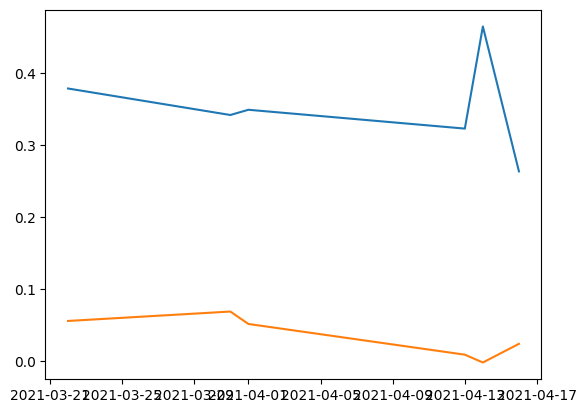

In [259]:
import matplotlib.pyplot as plt

ticker = 'TSLA'
call = get_cleaned_options_data(ticker, type='CALL').filter(pl.col('implied_vol') != 0.0)
put = get_cleaned_options_data(ticker, type='PUT').filter(pl.col('implied_vol') != 0.0)
exp = lambda i: call['expiration'].unique()[i]
iv_df = get_counts(call, put, get_average_iv_for_delta_bucket)
vol_df = get_counts(call, put, get_vol_of_iv_for_delta_bucket).join(realised_vol['trading_day','annualized_volatility'], on='trading_day', how='left')
vega_df = get_counts(call, put, get_vega).join(realised_vol['trading_day','annualized_volatility'], on='trading_day', how='left')
theta_df = get_counts(call, put, get_theta).join(realised_vol['trading_day','annualized_volatility'], on='trading_day', how='left')
count_df = get_counts(call, put, get_number_of_quotes).join(realised_vol['trading_day','annualized_volatility'], on='trading_day', how='left')
iv_df = iv_df.join(realised_vol['trading_day','annualized_volatility'], on='trading_day', how='left').sort('trading_day').with_columns([
    ((pl.col('otm_put_iv') - pl.col('otm_call_iv')) / pl.col('around_atm_put_iv')).alias('skew')
])
realised_vol = get_daily_volatility(ticker).rename({"timestamp": "trading_day"}).filter(pl.col('trading_day').is_in(call['trading_day']))



t = iv_df.filter(pl.col('expiration') == exp(18)).drop_nulls()
# col = 'skew'
col = 'skew'
print(t['trading_day','expiration',col][-5:])
# t = vol_df.filter_expiration('20210816')
x = t['trading_day']
r = t['annualized_volatility']
y1 = t[col]
plt.plot(x, r)
plt.plot(x, y1)

import numpy as np
np.corrcoef(r[:-1], y1[:-1])

In [204]:
print(call.head(5).to_pandas().to_markdown(index=False))

| ticker   | timestamp           |   strike | expiration          |   delta |   theta |   vega |     rho |   epsilon |   lambda |   implied_vol |   iv_error |   underlying_price |   price | trading_day         |   spread |
|:---------|:--------------------|---------:|:--------------------|--------:|--------:|-------:|--------:|----------:|---------:|--------------:|-----------:|-------------------:|--------:|:--------------------|---------:|
| GLD      | 2020-01-17 09:35:00 |   108000 | 2020-02-21 00:00:00 |  0.9999 | -0.0045 | 0.0061 | 10.3404 |  -14.0465 |   3.79   |        0.25   |     0      |             146.49 |  38.65  | 2020-01-17 00:00:00 |     0.2  |
| GLD      | 2020-01-17 09:35:00 |   111000 | 2020-02-21 00:00:00 |  1      |  0      | 0      |  0      |    0      |   0      |        0      |     0.0001 |             146.49 |  35.65  | 2020-01-17 00:00:00 |     0.2  |
| GLD      | 2020-01-17 09:35:00 |   114000 | 2020-02-21 00:00:00 |  0.9973 | -0.0063 | 0.3695 | 10.8772 |  

In [205]:
x = iv_df['deep_otm_call_iv'].to_numpy()
y = count_df['deep_otm_call_count'].to_numpy()
trading_day = iv_df['trading_day'].to_numpy()
plot_multivariate_kernel_density(x, y, 'deep_otm_call_iv', 'deep_otm_call_count', 'trading_day')

NameError: name 'plot_multivariate_kernel_density' is not defined

In [68]:
x

array([0.19431577, 0.19293512, 0.19454832, ..., 0.97199813, 1.17997512,
       3.11743071])

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from format import format_chart

@format_chart
def plot_multivariate_kernel_density(x, y, xlabel, ylabel, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot the 2D kernel density estimate
    sns.kdeplot(
        x=x, 
        y=y, 
        fill=True,
        cmap="rocket_r",
        cbar=True,
        ax=ax
    )


    # Add scatter plot of the data points
    ax.scatter(x, y,s=3.0, alpha=0.5, color="#FF0000")  

    
    # Add colorbar label
    cbar = ax.collections[0].colorbar
    cbar.set_label('Density')
    
    return ax
# plot_multivariate_kernel_density(x, y, xlabel='Realized Volatility', ylabel='Implied Volatility', title='NVDA Implied Volatility vs Realized Volatility')